In [ ]:
!kaggle --version


Kaggle CLI 2.0.2


In [ ]:
!kaggle datasets list -s food-101

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [ ]:
import os

os.environ["KAGGLE_API_TOKEN"] = input("Cole aqui seu Access Token do Kaggle: ").strip()

KeyboardInterrupt: Interrupted by user

In [ ]:
!kaggle competitions list

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [ ]:
!kaggle datasets list -s food-101

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [ ]:
!kaggle datasets download -d kmader/food41

Dataset URL: https://www.kaggle.com/datasets/kmader/food41
License(s): copyright-authors
100% 5.30G/5.30G [00:46<00:00, 122MB/s]



In [ ]:
!unzip -q food41.zip -d food101

In [ ]:
import os

print(os.listdir("food101"))

['food_c101_n10099_r32x32x1.h5', 'images', 'food_c101_n10099_r64x64x3.h5', 'food_test_c101_n1000_r64x64x1.h5', 'food_test_c101_n1000_r128x128x3.h5', 'food_c101_n10099_r64x64x1.h5', 'food_c101_n1000_r384x384x3.h5', 'food_test_c101_n1000_r32x32x3.h5', 'food_test_c101_n1000_r32x32x1.h5', 'food_test_c101_n1000_r64x64x3.h5', 'food_test_c101_n1000_r128x128x1.h5', 'food_c101_n10099_r32x32x3.h5']


In [ ]:
# Instalação (caso esteja no Google Colab)
!pip install -q tensorflow-datasets==4.9.9

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 43.0 MB/s eta 0:00:00


In [ ]:

import tensorflow as tf
import tensorflow_datasets as tfds

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

from sklearn.metrics import classification_report, confusion_matrix

import time
import os

ERROR:absl:Detected incompatible Protobuf Gencode/Runtime versions when loading tensorflow_metadata/proto/v0/anomalies.proto: gencode 6.31.1 runtime 5.29.6. Runtime version cannot be older than the linked gencode version. See Protobuf version guarantees at https://protobuf.dev/support/cross-version-runtime-guarantee.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/__init__.py", line 79, in <module>
    from tensorflow_datasets import rlds  # pylint: disable=g-bad-import-order
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/__init__.py", line 21, in <module>
    from tensorflow_datasets.rlds import envlogger_reader
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/envlogger_reader.py", line 21, in <module>
    from tensorflow_datasets.core.utils.lazy_imports_utils import tree
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/co

In [ ]:
!pip show tensorflow-datasets

Name: tensorflow-datasets
Version: 4.9.9
Summary: tensorflow/datasets is a library of datasets ready to use with TensorFlow.
Home-page: https://github.com/tensorflow/datasets
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: absl-py, array_record, dm-tree, etils, immutabledict, numpy, promise, protobuf, psutil, pyarrow, requests, simple_parsing, tensorflow-metadata, termcolor, toml, tqdm, wrapt
Required-by: 


In [ ]:
!pip uninstall -y tensorflow-datasets
!pip install tensorflow-datasets==4.9.9

Found existing installation: tensorflow-datasets 4.9.9
Uninstalling tensorflow-datasets-4.9.9:
  Successfully uninstalled tensorflow-datasets-4.9.9
  Using cached tensorflow_datasets-4.9.9-py3-none-any.whl.metadata (11 kB)
Using cached tensorflow_datasets-4.9.9-py3-none-any.whl (5.3 MB)


In [ ]:
import tensorflow_datasets as tfds

print(dir(tfds)[:30])

ERROR:absl:Detected incompatible Protobuf Gencode/Runtime versions when loading tensorflow_metadata/proto/v0/anomalies.proto: gencode 6.31.1 runtime 5.29.6. Runtime version cannot be older than the linked gencode version. See Protobuf version guarantees at https://protobuf.dev/support/cross-version-runtime-guarantee.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/__init__.py", line 79, in <module>
    from tensorflow_datasets import rlds  # pylint: disable=g-bad-import-order
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/__init__.py", line 21, in <module>
    from tensorflow_datasets.rlds import envlogger_reader
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/envlogger_reader.py", line 21, in <module>
    from tensorflow_datasets.core.utils.lazy_imports_utils import tree
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/co

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'annotations', 'audio', 'd4rl', 'datasets', 'graphs', 'image', 'image_classification', 'logging', 'nearest_neighbors', 'object_detection', 'question_answering', 'ranking', 'recommendation', 'rl_unplugged', 'robomimic', 'robotics', 'structured', 'summarization', 'text', 'text_simplification', 'time_series']


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import time

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
dataset_path = "food101/images"

print(os.listdir(dataset_path)[:10])

['club_sandwich', 'macarons', 'frozen_yogurt', 'croque_madame', 'creme_brulee', 'onion_rings', 'baby_back_ribs', 'french_toast', 'caprese_salad', 'lobster_bisque']


In [ ]:
classes_escolhidas = [
    "apple_pie",
    "baby_back_ribs",
    "baklava",
    "beef_carpaccio",
    "beef_tartare",
    "beet_salad",
    "beignets",
    "bibimbap",
    "bread_pudding",
    "breakfast_burrito",
    "caesar_salad",
    "cannoli",
    "caprese_salad",
    "carrot_cake",
    "ceviche",
    "cheesecake",
    "cheese_plate",
    "chicken_curry",
    "chicken_quesadilla",
    "chicken_wings"
]


NUM_CLASSES = len(classes_escolhidas)

print("Número de classes:", NUM_CLASSES)

Número de classes: 20


In [ ]:
for classe in classes_escolhidas:
    caminho = os.path.join(dataset_path, classe)

    quantidade = len(os.listdir(caminho))

    print(classe, ":", quantidade)

apple_pie : 1000
baby_back_ribs : 1000
baklava : 1000
beef_carpaccio : 1000
beef_tartare : 1000
beet_salad : 1000
beignets : 1000
bibimbap : 1000
bread_pudding : 1000
breakfast_burrito : 1000
caesar_salad : 1000
cannoli : 1000
caprese_salad : 1000
carrot_cake : 1000
ceviche : 1000
cheesecake : 1000
cheese_plate : 1000
chicken_curry : 1000
chicken_quesadilla : 1000
chicken_wings : 1000


In [ ]:
import pandas as pd


imagens = []
rotulos = []


for classe in classes_escolhidas:

    pasta = os.path.join(dataset_path, classe)

    for img in os.listdir(pasta):

        caminho_img = os.path.join(
            classe,
            img
        )

        imagens.append(caminho_img)
        rotulos.append(classe)


df = pd.DataFrame({
    "arquivo": imagens,
    "classe": rotulos
})


df.head()

,arquivo,classe
0,apple_pie/3634716.jpg,apple_pie
1,apple_pie/2536578.jpg,apple_pie
2,apple_pie/3506848.jpg,apple_pie
3,apple_pie/2918880.jpg,apple_pie
4,apple_pie/3833386.jpg,apple_pie


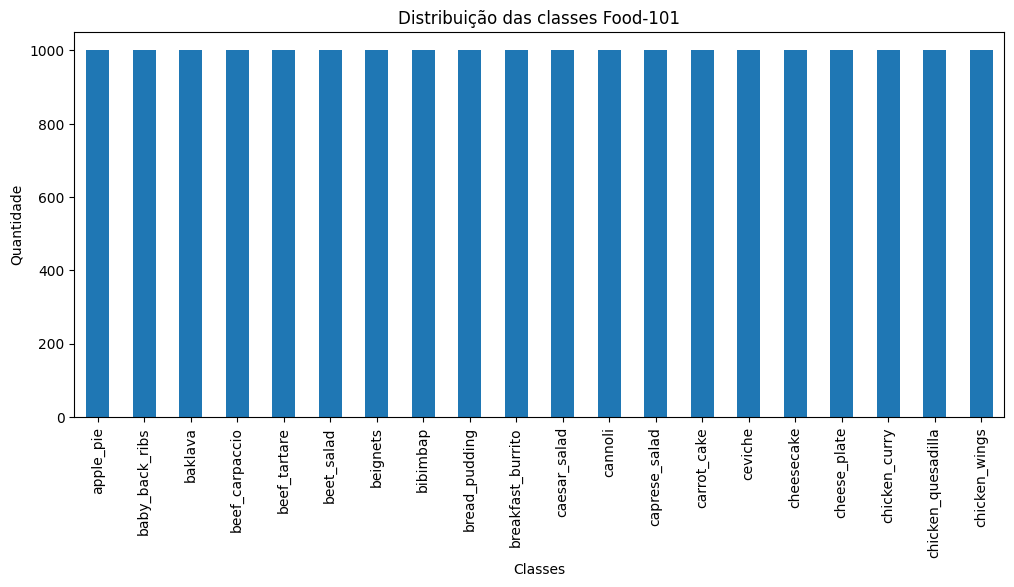

In [ ]:
plt.figure(figsize=(12,5))

df["classe"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Distribuição das classes Food-101"
)

plt.xlabel("Classes")
plt.ylabel("Quantidade")

plt.xticks(rotation=90)

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split


train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["classe"],
    random_state=SEED
)


val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["classe"],
    random_state=SEED
)


print("Treino:", len(train_df))
print("Validação:", len(val_df))
print("Teste:", len(test_df))

Treino: 14000
Validação: 3000
Teste: 3000


In [ ]:
IMG_SIZE = (224,224)

BATCH_SIZE = 32

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

In [ ]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory=dataset_path,
    x_col="arquivo",
    y_col="classe",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)


val_generator = test_datagen.flow_from_dataframe(
    val_df,
    directory=dataset_path,
    x_col="arquivo",
    y_col="classe",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)


test_generator = test_datagen.flow_from_dataframe(
    test_df,
    directory=dataset_path,
    x_col="arquivo",
    y_col="classe",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 14000 validated image filenames belonging to 20 classes.
Found 3000 validated image filenames belonging to 20 classes.
Found 3000 validated image filenames belonging to 20 classes.


In [ ]:
class_indices = train_generator.class_indices

class_names = list(class_indices.keys())

print(class_names)

['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito', 'caesar_salad', 'cannoli', 'caprese_salad', 'carrot_cake', 'ceviche', 'cheese_plate', 'cheesecake', 'chicken_curry', 'chicken_quesadilla', 'chicken_wings']


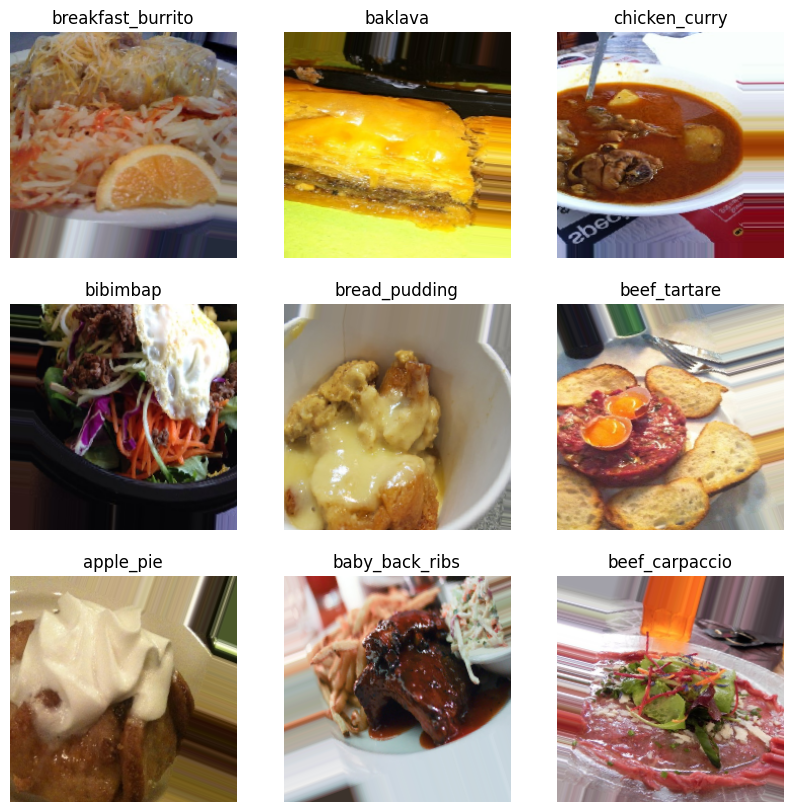

In [ ]:
images, labels = next(train_generator)


plt.figure(figsize=(10,10))


for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.title(
        class_names[np.argmax(labels[i])]
    )

    plt.axis("off")


plt.show()

In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)


base_model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "densenet121"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,037,504 (26.85 MB)

 Trainable params: 6,953,856 (26.53 MB)

 Non-trainable params: 83,648 (326.75 KB)

In [ ]:
base_model.trainable = False

In [ ]:
print(
    "Camadas congeladas:",
    len(base_model.layers)
)

Camadas congeladas: 427


In [ ]:
x = base_model.output


x = GlobalAveragePooling2D()(x)


x = Dense(
    512,
    activation="relu"
)(x)


x = Dropout(
    0.5
)(x)


output = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)


model_adam = Model(
    inputs=base_model.input,
    outputs=output
)

In [ ]:
model_adam.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,572,564 (28.89 MB)

 Trainable params: 535,060 (2.04 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
model_adam.compile(
    optimizer=Adam(
        learning_rate=0.0001
    ),

    loss="categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


checkpoint_adam = ModelCheckpoint(
    "densenet_adam_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

In [ ]:
inicio = time.time()

history_adam = model_adam.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    steps_per_epoch=15,
    validation_steps=10,
    callbacks=[
        early_stop,
        checkpoint_adam
    ]
)

fim = time.time()

tempo_adam = fim - inicio

print("Tempo de treinamento:", tempo_adam/60, "minutos")

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 142s 10s/step - accuracy: 0.1312 - loss: 2.8558 - val_accuracy: 0.2250 - val_loss: 2.6197
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 141s 10s/step - accuracy: 0.1562 - loss: 2.7902 - val_accuracy: 0.2969 - val_loss: 2.5495
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 139s 10s/step - accuracy: 0.1854 - loss: 2.6855 - val_accuracy: 0.2719 - val_loss: 2.5104
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 139s 10s/step - accuracy: 0.1813 - loss: 2.6791 - val_accuracy: 0.3313 - val_loss: 2.4509
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 142s 10s/step - accuracy: 0.1896 - loss: 2.6224 - val_accuracy: 0.3375 - val_loss: 2.3942
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 140s 10s/step - accuracy: 0.2021 - loss: 2.6190 - val_accuracy: 0.3750 - val_loss: 2.3636
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 140s 10s/step - accuracy: 0.2500 - loss: 2.5405 - val_accuracy: 0.3750 - val_loss: 2.3058
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 143s 10s/step - accuracy: 0.2729 - loss: 2.4308 - val_accuracy: 0.

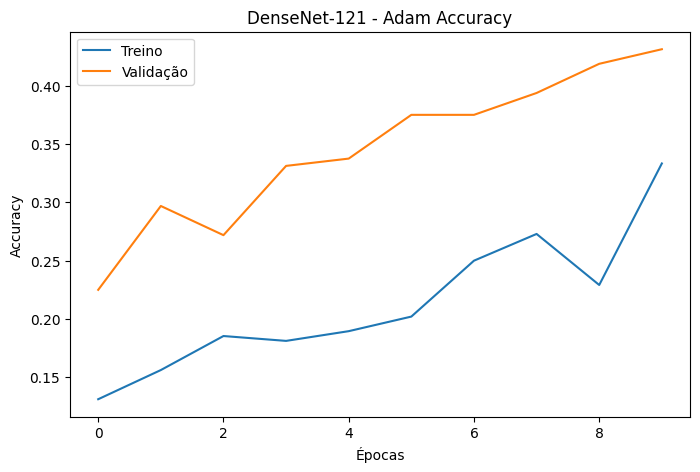

In [ ]:
plt.figure(figsize=(8,5))


plt.plot(
    history_adam.history["accuracy"],
    label="Treino"
)


plt.plot(
    history_adam.history["val_accuracy"],
    label="Validação"
)


plt.title(
    "DenseNet-121 - Adam Accuracy"
)


plt.xlabel(
    "Épocas"
)


plt.ylabel(
    "Accuracy"
)


plt.legend()

plt.show()

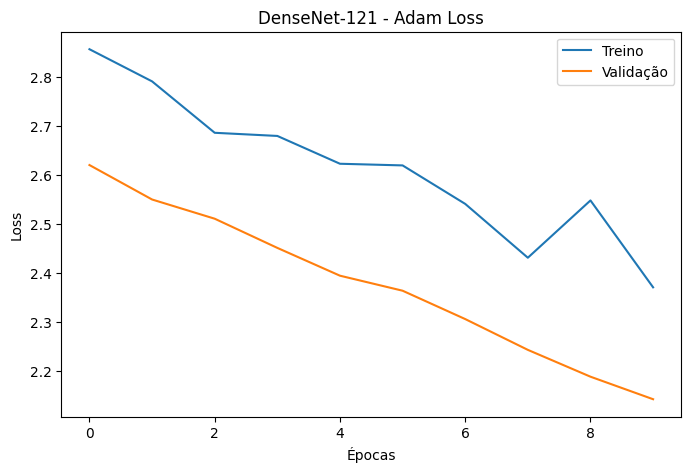

In [ ]:
plt.figure(figsize=(8,5))


plt.plot(
    history_adam.history["loss"],
    label="Treino"
)


plt.plot(
    history_adam.history["val_loss"],
    label="Validação"
)


plt.title(
    "DenseNet-121 - Adam Loss"
)


plt.xlabel(
    "Épocas"
)


plt.ylabel(
    "Loss"
)


plt.legend()

plt.show()

In [ ]:
loss_adam, acc_adam = model_adam.evaluate(
    test_generator
)


print(
    "Accuracy Adam:",
    acc_adam
)

94/94 ━━━━━━━━━━━━━━━━━━━━ 499s 5s/step - accuracy: 0.4213 - loss: 2.1667
Accuracy Adam: 0.42133334279060364


In [ ]:
from tensorflow.keras.optimizers import SGD

In [ ]:
base_model_sgd = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model_sgd.trainable = False

In [ ]:
x = base_model_sgd.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    512,
    activation="relu"
)(x)

x = Dropout(0.5)(x)

output = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model_sgd = Model(
    inputs=base_model_sgd.input,
    outputs=output
)

In [ ]:
model_sgd.compile(
    optimizer=SGD(
        learning_rate=0.001,
        momentum=0.9
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
checkpoint_sgd = ModelCheckpoint(
    "densenet_sgd_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

In [ ]:
inicio = time.time()

history_sgd = model_sgd.fit(
    train_generator,
    validation_data=val_generator,
    epochs=3,
    steps_per_epoch=30,
    validation_steps=10,
    callbacks=[
        early_stop,
        checkpoint_sgd
    ]
)

fim = time.time()

tempo_sgd = fim - inicio

print("Tempo:", tempo_sgd/60, "min")

Epoch 1/3
30/30 ━━━━━━━━━━━━━━━━━━━━ 247s 8s/step - accuracy: 0.0729 - loss: 3.4513 - val_accuracy: 0.1125 - val_loss: 2.8782
Epoch 2/3
30/30 ━━━━━━━━━━━━━━━━━━━━ 224s 8s/step - accuracy: 0.1333 - loss: 2.8787 - val_accuracy: 0.2594 - val_loss: 2.5623
Epoch 3/3
30/30 ━━━━━━━━━━━━━━━━━━━━ 262s 9s/step - accuracy: 0.1844 - loss: 2.6974 - val_accuracy: 0.3375 - val_loss: 2.3944
Tempo: 12.692685282230377 min


In [ ]:
loss_sgd, acc_sgd = model_sgd.evaluate(test_generator)

print("Accuracy:", acc_sgd)

94/94 ━━━━━━━━━━━━━━━━━━━━ 493s 5s/step - accuracy: 0.1257 - loss: 2.8700
Accuracy: 0.12566666305065155


In [ ]:
from sklearn.metrics import accuracy_score

pred = model_sgd.predict(test_generator)

y_pred = np.argmax(pred, axis=1)

y_true = test_generator.classes

top1 = accuracy_score(y_true, y_pred)

print("Top-1 Accuracy:", top1)

94/94 ━━━━━━━━━━━━━━━━━━━━ 510s 5s/step
Top-1 Accuracy: 0.12566666666666668


In [ ]:
top5 = tf.keras.metrics.TopKCategoricalAccuracy(k=5)

top5.update_state(
    tf.keras.utils.to_categorical(
        y_true,
        NUM_CLASSES
    ),
    pred
)

print(
    "Top-5 Accuracy:",
    top5.result().numpy()
)

Top-5 Accuracy: 0.436


In [ ]:
precision = precision_score(
    y_true,
    y_pred,
    average="macro"
)

print(
    "Precision:",
    precision
)

Precision: 0.14818814739048858


In [ ]:
recall = recall_score(
    y_true,
    y_pred,
    average="macro"
)

print(
    "Recall:",
    recall
)

Recall: 0.12566666666666668


In [ ]:
f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

print(
    "F1:",
    f1
)

F1: 0.10752838041976576


In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                    precision    recall  f1-score   support

         apple_pie       0.00      0.00      0.00       150
    baby_back_ribs       0.04      0.11      0.06       150
           baklava       0.02      0.01      0.01       150
    beef_carpaccio       0.26      0.08      0.12       150
      beef_tartare       0.09      0.03      0.04       150
        beet_salad       0.00      0.00      0.00       150
          beignets       0.29      0.15      0.19       150
          bibimbap       0.58      0.21      0.31       150
     bread_pudding       0.37      0.05      0.08       150
 breakfast_burrito       0.14      0.14      0.14       150
      caesar_salad       0.13      0.56      0.21       150
           cannoli       0.09      0.13      0.11       150
     caprese_salad       0.12      0.22      0.16       150
       carrot_cake       0.07      0.19      0.10       150
           ceviche       0.11      0.06      0.08       150
      cheese_plate       0.10      0.07

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

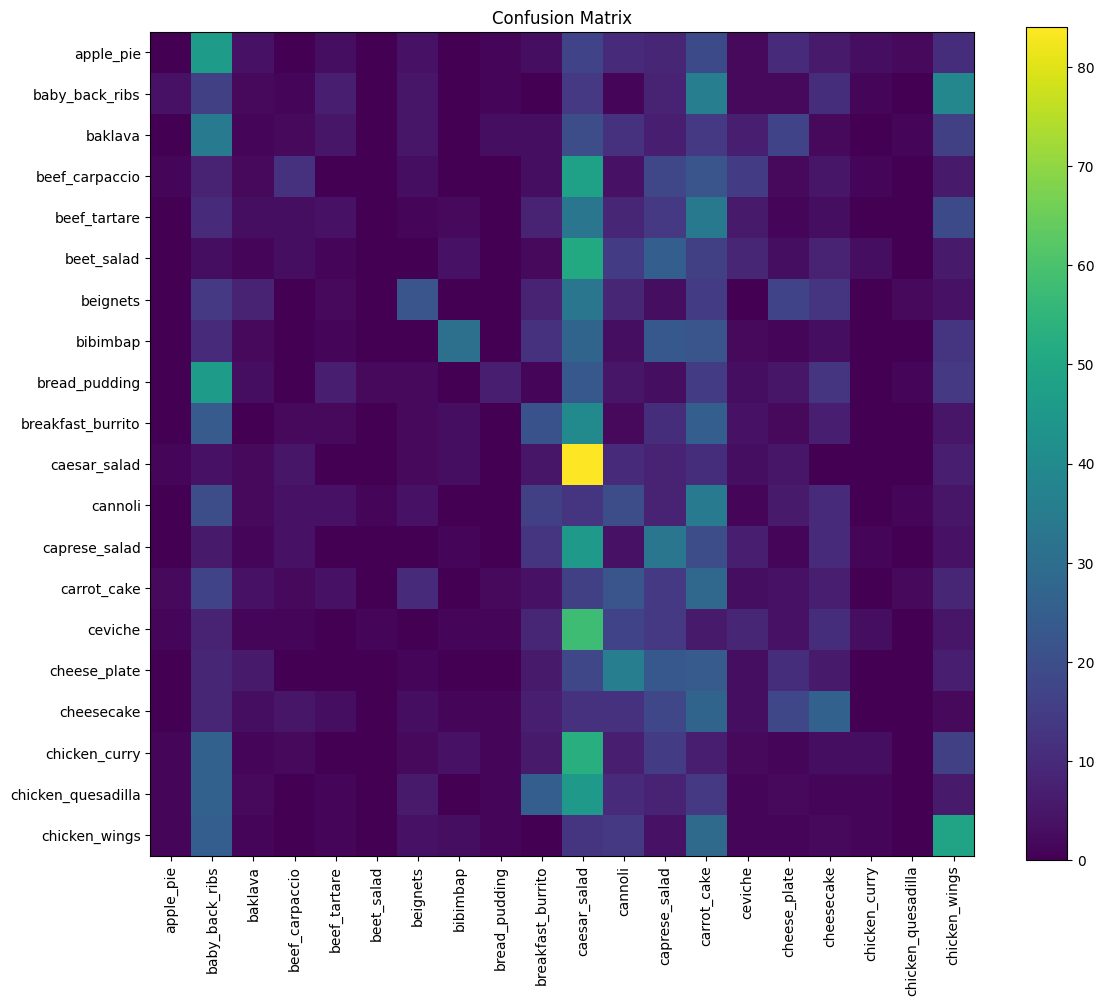

In [ ]:
plt.figure(figsize=(12,10))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks(
    np.arange(NUM_CLASSES),
    class_names,
    rotation=90
)

plt.yticks(
    np.arange(NUM_CLASSES),
    class_names
)

plt.tight_layout()

plt.show()

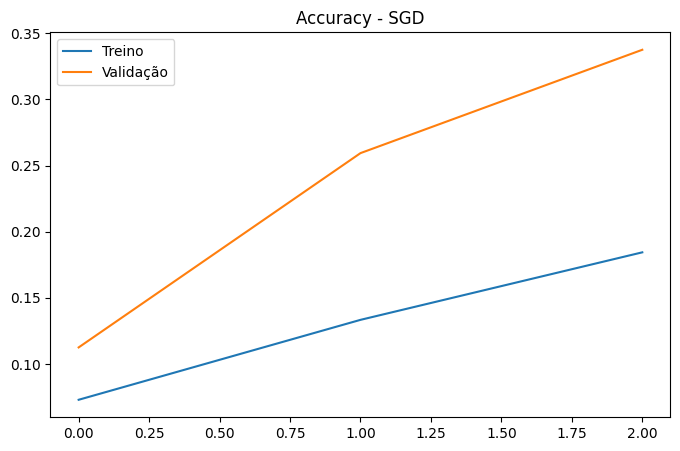

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history_sgd.history["accuracy"],
    label="Treino"
)

plt.plot(
    history_sgd.history["val_accuracy"],
    label="Validação"
)

plt.title("Accuracy - SGD")

plt.legend()

plt.show()

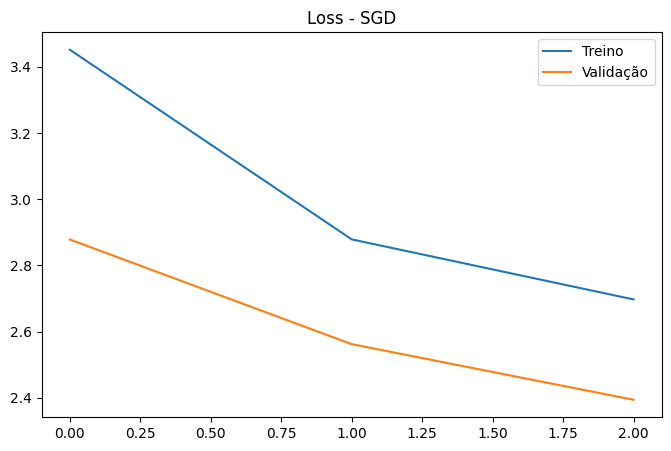

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history_sgd.history["loss"],
    label="Treino"
)

plt.plot(
    history_sgd.history["val_loss"],
    label="Validação"
)

plt.title("Loss - SGD")

plt.legend()

plt.show()

In [ ]:
import pandas as pd

resultado = pd.DataFrame({

    "Modelo":[
        "DenseNet121 + Adam",
        "DenseNet121 + SGD"
    ],

    "Accuracy":[
        acc_adam,
        acc_sgd
    ],

    "Tempo (min)":[
        tempo_adam/60,
        tempo_sgd/60
    ]

})

resultado

,Modelo,Accuracy,Tempo (min)
0,DenseNet121 + Adam,0.421333,23.984631
1,DenseNet121 + SGD,0.125667,12.692685


In [ ]:
resultado.to_csv(
    "comparacao_modelos.csv",
    index=False
)

In [ ]:
model_adam.save(
    "DenseNet121_Adam.keras"
)

model_sgd.save(
    "DenseNet121_SGD.keras"
)